# MAAI Bootcamp :: Activity: End-to-end ML

## Introduction

In this exercise, you will work with a small dataset called *Amsterdam Housing Prices*. The objective is very similar to the example we have seen before: Based on the features of the dataset, you should predict the price of the property.

Your task is develop the necessary tasks for each step.



## 1. Look at the big picture

Hint: You should frame the problem and define one or more performance measures

## 2. Get the data

The code below opens the Amsterdam Housing dataset, available [here](https://www.kaggle.com/datasets/thomasnibb/amsterdam-house-price-prediction).

In [494]:
import pandas as pd

def load_housing_data():
    return pd.read_csv('exercise_dataset/HousingPrices-Amsterdam-August-2021.csv')
    
housing = load_housing_data()

housing.columns = housing.columns.str.lower()

housing.head()

,unnamed: 0,address,zip,price,area,room,lon,lat
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [495]:
# List all unique values in the unnamed column
# housing['Unnamed: 0'].unique()

## Initial look at data

The data set for the housing has some features that don't seem very relevant. There's an unnamed row that seems to contain the number / id's of the set. But the pandas data frame already has a numbering starting at 0 so this one should be dropped.

The adress doesn't seem the most usable because there's a lot of them the same goes for the zip codes but less so. An option to use these would be to drop the numberings and keep only the zipcode numbers and the street names. And then encode the street names with onehot encoding but this would create a big amount of values.

A better option to use the locations is to use the data from the amsterdam districts and use the available lon, lat values to determine the zone they are located in and then remove the other geographical data. 

An extra thing that can be done is calculate the distance from a specific adress to the city center district because this might have interesting data, or to get the distance to any of the big locations for getting on public transit like central station, amstel station, station zuid and sloterdijk. 

For now for simplicity I will start with only the district location and drop the other data.


## Import geographical data and distrcits off amsterdam

In [496]:
import geopandas as gpd

def load_district_data():
    return gpd.read_file('exercise_dataset/geojson_lnglat.json')

districts = load_district_data()

districts.head()

,Stadsdeelcode,Stadsdeel,Oppervlakte_m2,geometry
0,A,Centrum,8012895,"POLYGON ((4.87817 52.37851, 4.8781 52.3784, 4...."
1,M,Oost,30479187,"POLYGON ((4.9118 52.33946, 4.91118 52.33931, 4..."
2,B,Westpoort,28880754,"POLYGON ((4.85608 52.41666, 4.85548 52.41677, ..."
3,F,Nieuw-West,37870831,"POLYGON ((4.75749 52.39689, 4.7576 52.39685, 4..."
4,T,Zuidoost,19809557,"POLYGON ((4.99808 52.31404, 4.99786 52.31398, ..."


## Infer the district for each house and add it to the data.

In [497]:
import geopandas as gpd
from shapely.geometry import Point

housing_gdf = gpd.GeoDataFrame(
    housing,
    geometry=[Point(xy) for xy in zip(housing['lon'], housing['lat'])],
    crs="EPSG:4326"
)

districts = districts.to_crs(housing_gdf.crs)

housing_with_districts = gpd.sjoin(housing_gdf, districts, how="left", predicate="intersects")

housing['stadsdeel'] = housing_with_districts['Stadsdeel']

housing.head()

,unnamed: 0,address,zip,price,area,room,lon,lat,stadsdeel
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157,Oost
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586,Zuid
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782,Oost
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712,Nieuw-West
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538,Noord


## Dropping redundant data

In [498]:
# Drop the 'Unnamed: 0' and 'Address' columns
housing = housing.drop(columns=['unnamed: 0', 'address', 'zip', 'lon', 'lat'])

# Remove letters from the 'zipcode' column and keep only the numeric part
# housing = housing.assign(zipcode_number=housing['zip'].str.extract(r'(\d+)').astype(int)).drop(columns=['zip'])

housing.head()

,price,area,room,stadsdeel
0,685000.0,64,3,Oost
1,475000.0,60,3,Zuid
2,850000.0,109,4,Oost
3,580000.0,128,6,Nieuw-West
4,720000.0,138,5,Noord


## Inspect and handle null values

In [499]:
null_counts = housing.isnull().sum()
print("Null values in each column:")
print(null_counts)

# Drop columns with null values
housing = housing.dropna(axis=0)
print("Columns after dropping null values:")
print(housing.columns)

Null values in each column:
price        4
area         0
room         0
stadsdeel    2
dtype: int64
Columns after dropping null values:
Index(['price', 'area', 'room', 'stadsdeel'], dtype='object')


Because there's only 4 rows with a null value those will be dropped

In [500]:
housing.describe()

,price,area,room
count,9.180000e+02,918.000000,918.000000
mean,6.214327e+05,95.553377,3.559913
std,5.394079e+05,56.896766,1.568572
min,1.750000e+05,21.000000,1.000000
25%,3.500000e+05,60.000000,3.000000
50%,4.650000e+05,83.000000,3.000000
75%,6.990000e+05,112.750000,4.000000
max,5.950000e+06,623.000000,14.000000


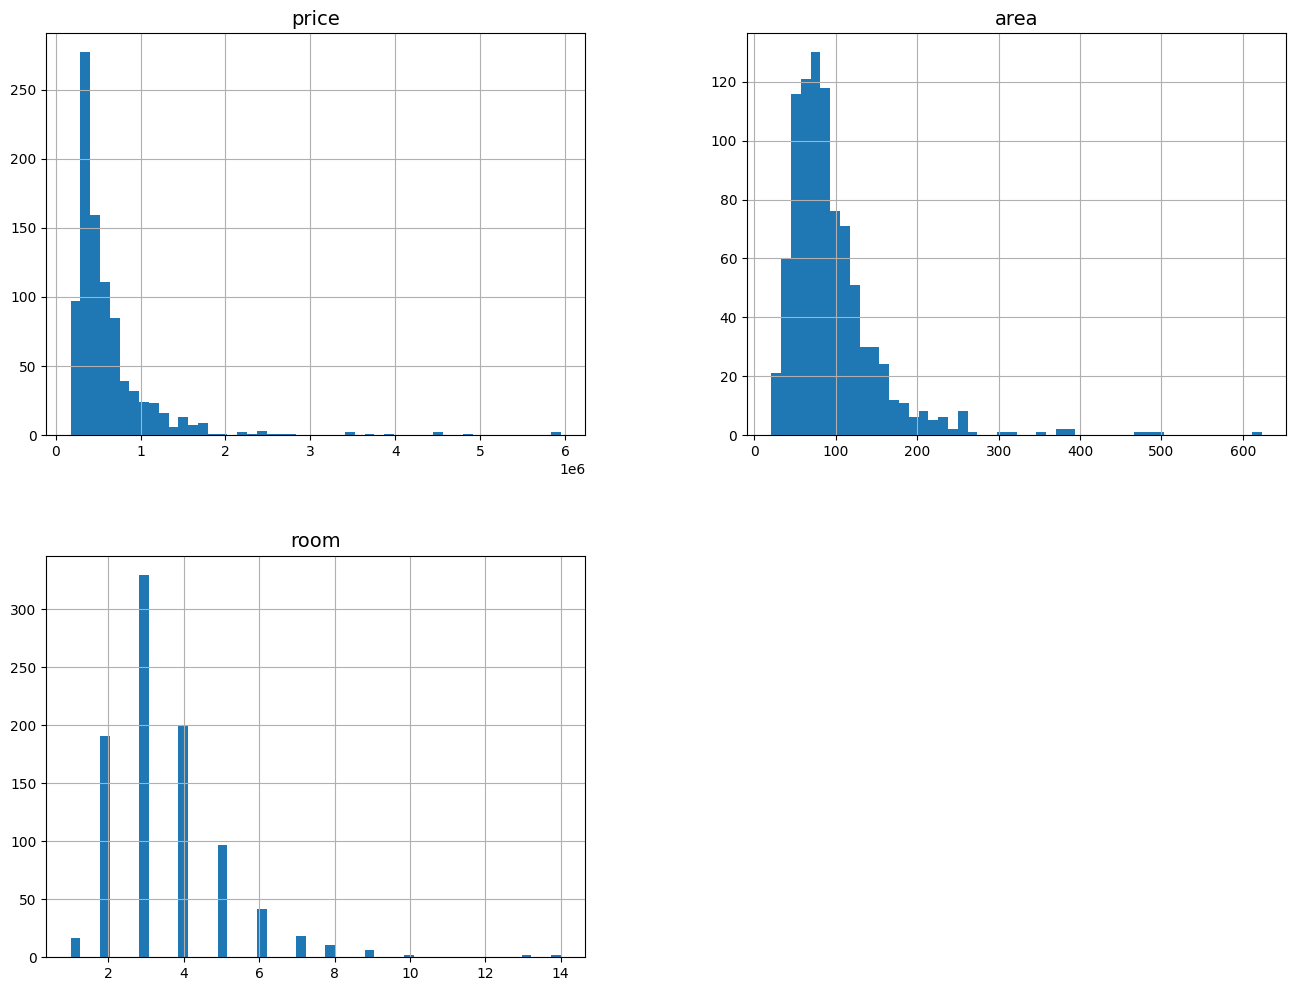

In [501]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(16,12))
plt.show()

In [502]:
# import matplotlib.pyplot as plt

# # Adjust column names based on your dataset
# housing.plot(kind="scatter", x="lon", y="lat", grid=True,
#              s=housing["zipcode_number"] / 100, label="Population",
#              c="price", cmap="jet", colorbar=True,
#              legend=True, sharex=False, figsize=(10, 7))
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("Geographical Distribution of Housing Prices")
# plt.show()

## Look at correlations

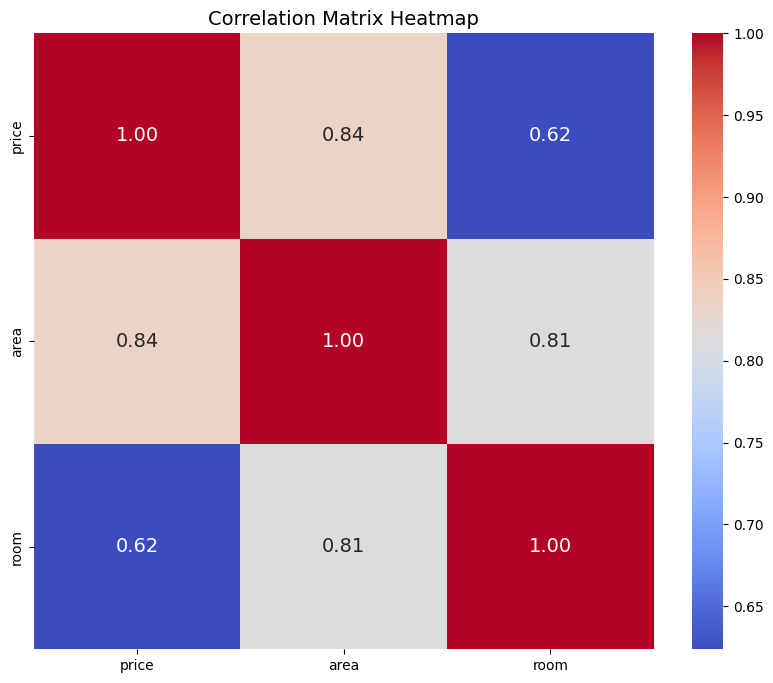

Correlation Matrix:
          price      area      room
price  1.000000  0.835030  0.623709
area   0.835030  1.000000  0.809008
room   0.623709  0.809008  1.000000


In [503]:
import seaborn as sns
import matplotlib.pyplot as plt

# Exclude non-numeric columns before calculating the correlation matrix
numeric_housing = housing.select_dtypes(include=['number'])
correlation_matrix = numeric_housing.corr()

# Visualize the correlation matrix using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Log the correlation values
print("Correlation Matrix:")
print(correlation_matrix)

## Housing price per district

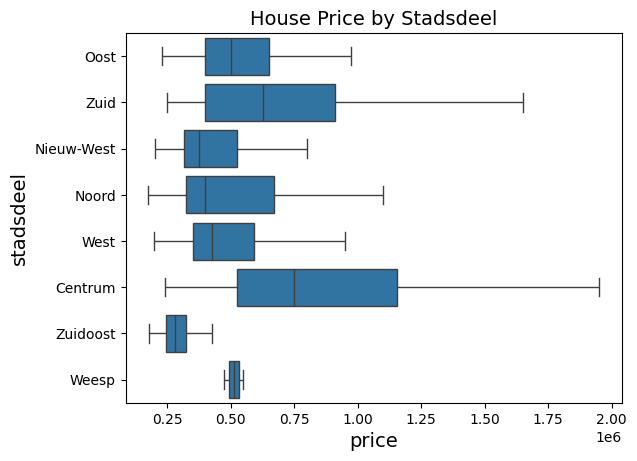

In [504]:
sns.boxplot(y='stadsdeel', x='price', data=housing, showfliers=False)
plt.title("House Price by Stadsdeel")
plt.show()

## One hot encode the districts


In [505]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode the 'stadsdeel' column
ohe = OneHotEncoder(sparse_output=False, drop='first')
district_encoded = ohe.fit_transform(housing[['stadsdeel']])

district_encoded_df = pd.DataFrame(
    district_encoded, 
    columns=ohe.get_feature_names_out(['stadsdeel']),
    index=housing.index
)

# Concatenate the one-hot encoded columns with the original dataframe
housing = pd.concat([housing, district_encoded_df], axis=1)

housing.head()

,price,area,room,stadsdeel,stadsdeel_Nieuw-West,stadsdeel_Noord,stadsdeel_Oost,stadsdeel_Weesp,stadsdeel_West,stadsdeel_Zuid,stadsdeel_Zuidoost
0,685000.0,64,3,Oost,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,475000.0,60,3,Zuid,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,850000.0,109,4,Oost,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,580000.0,128,6,Nieuw-West,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,720000.0,138,5,Noord,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Explore and visualize the data to gain insights


In [506]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Ensure there are no missing values in the 'stadsdeel' column
housing = housing.dropna(subset=['stadsdeel'])

# Perform stratified split based on 'stadsdeel'
train_set, test_set = train_test_split(housing, test_size=0.2, stratify=housing['stadsdeel'])

# One-hot encode the 'stadsdeel' column for training and test sets
ohe = OneHotEncoder(sparse_output=False, drop='first')
train_district_encoded = ohe.fit_transform(train_set[['stadsdeel']])
test_district_encoded = ohe.transform(test_set[['stadsdeel']])

train_district_encoded_df = pd.DataFrame(
    train_district_encoded, 
    columns=ohe.get_feature_names_out(['stadsdeel']),
    index=train_set.index
)

test_district_encoded_df = pd.DataFrame(
    test_district_encoded, 
    columns=ohe.get_feature_names_out(['stadsdeel']),
    index=test_set.index
)

# Concatenate the one-hot encoded columns with the original dataframes
train_set = pd.concat([train_set, train_district_encoded_df], axis=1)
test_set = pd.concat([test_set, test_district_encoded_df], axis=1)

# Select numeric columns for scaling
numeric_columns = train_set.select_dtypes(include=['number']).columns

# Initialize the scaler
scaler = StandardScaler()

# Apply scaling to numeric columns in training and test sets
train_set[numeric_columns] = scaler.fit_transform(train_set[numeric_columns])
test_set[numeric_columns] = scaler.transform(test_set[numeric_columns])

# Verify the stratification
print("Proportion of districts in the original dataset:")
print(housing['stadsdeel'].value_counts(normalize=True))

print("\nProportion of districts in the training set:")
print(train_set['stadsdeel'].value_counts(normalize=True))

print("\nProportion of districts in the testing set:")
print(test_set['stadsdeel'].value_counts(normalize=True))

Proportion of districts in the original dataset:
stadsdeel
West          0.199346
Nieuw-West    0.163399
Centrum       0.156863
Zuid          0.149237
Oost          0.130719
Noord         0.114379
Zuidoost      0.083878
Weesp         0.002179
Name: proportion, dtype: float64

Proportion of districts in the training set:
stadsdeel
West          0.198910
Nieuw-West    0.163488
Centrum       0.156676
Zuid          0.148501
Oost          0.130790
Noord         0.114441
Zuidoost      0.084469
Weesp         0.002725
Name: proportion, dtype: float64

Proportion of districts in the testing set:
stadsdeel
West          0.201087
Nieuw-West    0.163043
Centrum       0.157609
Zuid          0.152174
Oost          0.130435
Noord         0.114130
Zuidoost      0.081522
Name: proportion, dtype: float64


Hints:
- Visualise distributions
- Find correlations
- Try out some attribute combinations or data augmentation

## Prepare the data for machine learning algorithms


Hints:
- Check the existence of missing values
- Apply transformations such as feature scaling

In [507]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns for scaling
numeric_columns = housing.select_dtypes(include=['number']).columns

# Initialize the scaler
scaler = StandardScaler()

# Apply scaling to numeric columns
housing[numeric_columns] = scaler.fit_transform(housing[numeric_columns])

# Verify the scaled data
housing.describe()

,price,area,room,stadsdeel_Nieuw-West,stadsdeel_Noord,stadsdeel_Oost,stadsdeel_Weesp,stadsdeel_West,stadsdeel_Zuid,stadsdeel_Zuidoost
count,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,918.000000,9.180000e+02,9.180000e+02,9.180000e+02
mean,-1.548023e-17,7.740117e-17,-8.901134e-17,-3.096047e-17,-4.063561e-17,-3.096047e-17,0.000000,-3.870058e-18,-8.030371e-17,2.322035e-17
std,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00,1.000545,1.000545e+00,1.000545e+00,1.000545e+00
min,-8.280858e-01,-1.311041e+00,-1.632891e+00,-4.419417e-01,-3.593763e-01,-3.877834e-01,-0.046727,-4.989785e-01,-4.188271e-01,-3.025850e-01
25%,-5.034791e-01,-6.252158e-01,-3.571515e-01,-4.419417e-01,-3.593763e-01,-3.877834e-01,-0.046727,-4.989785e-01,-4.188271e-01,-3.025850e-01
50%,-2.901662e-01,-2.207545e-01,-3.571515e-01,-4.419417e-01,-3.593763e-01,-3.877834e-01,-0.046727,-4.989785e-01,-4.188271e-01,-3.025850e-01
75%,1.438793e-01,3.024073e-01,2.807183e-01,-4.419417e-01,-3.593763e-01,-3.877834e-01,-0.046727,-4.989785e-01,-4.188271e-01,-3.025850e-01
max,9.883934e+00,9.275292e+00,6.659417e+00,2.262742e+00,2.782599e+00,2.578759e+00,21.400935,2.004094e+00,2.387620e+00,3.304857e+00


In [508]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 923
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 918 non-null    float64
 1   area                  918 non-null    float64
 2   room                  918 non-null    float64
 3   stadsdeel             918 non-null    object 
 4   stadsdeel_Nieuw-West  918 non-null    float64
 5   stadsdeel_Noord       918 non-null    float64
 6   stadsdeel_Oost        918 non-null    float64
 7   stadsdeel_Weesp       918 non-null    float64
 8   stadsdeel_West        918 non-null    float64
 9   stadsdeel_Zuid        918 non-null    float64
 10  stadsdeel_Zuidoost    918 non-null    float64
dtypes: float64(10), object(1)
memory usage: 86.1+ KB


In [509]:
housing.head()

,price,area,room,stadsdeel,stadsdeel_Nieuw-West,stadsdeel_Noord,stadsdeel_Oost,stadsdeel_Weesp,stadsdeel_West,stadsdeel_Zuid,stadsdeel_Zuidoost
0,0.117911,-0.554875,-0.357152,Oost,-0.441942,-0.359376,2.578759,-0.046727,-0.498979,-0.418827,-0.302585
1,-0.271617,-0.625216,-0.357152,Zuid,-0.441942,-0.359376,-0.387783,-0.046727,-0.498979,2.387620,-0.302585
2,0.423968,0.236463,0.280718,Oost,-0.441942,-0.359376,2.578759,-0.046727,-0.498979,-0.418827,-0.302585
3,-0.076853,0.570583,1.556458,Nieuw-West,2.262742,-0.359376,-0.387783,-0.046727,-0.498979,-0.418827,-0.302585
4,0.182832,0.746435,0.918588,Noord,-0.441942,2.782599,-0.387783,-0.046727,-0.498979,-0.418827,-0.302585


## 5. Select a model and train it


Hints:
- You can use the models shown in the example (e.g. Linear regression, Decision Trees, Random Forests)
- Feel free to choose different ones (e.g. XGBoost, SVR)

In [510]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Ensure all numeric columns, including one-hot encoded stadsdeel, are used for training
train_features = train_set.select_dtypes(include=['number']).drop(columns=['price'])
test_features = test_set.select_dtypes(include=['number']).drop(columns=['price'])

# Train the model
lin_reg = LinearRegression()
lin_reg.fit(train_features, train_set['price'])

# Predict and evaluate
lin_predictions = lin_reg.predict(test_features)
lin_mse = mean_squared_error(test_set['price'], lin_predictions)
lin_rmse = np.sqrt(lin_mse)

# Evaluate RMSE relative to the mean price
mean_price = train_set['price'].mean()
rmse_percentage = (lin_rmse / mean_price) * 100

print(f"Linear Regression RMSE: {lin_rmse}")
print(f"RMSE as percentage of mean price: {rmse_percentage:.2f}%")

Linear Regression RMSE: 0.3234054296946354
RMSE as percentage of mean price: -2324049157248193024.00%


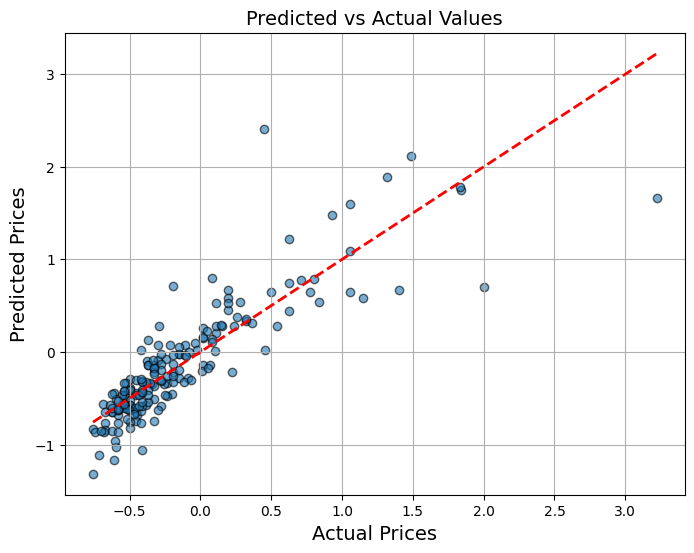

In [511]:
# Visualize Predicted vs Actual Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(test_set['price'], lin_predictions, alpha=0.6, edgecolor='k')
plt.plot([test_set['price'].min(), test_set['price'].max()], 
         [test_set['price'].min(), test_set['price'].max()], 'r--', lw=2)
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

In [512]:
# # Decision Tree Model
# from sklearn.tree import DecisionTreeRegressor

# # Train the model
# tree_reg = DecisionTreeRegressor(random_state=42)
# tree_reg.fit(train_set.drop(columns=['price']), train_set['price'])

# # Predict and evaluate
# tree_predictions = tree_reg.predict(test_set.drop(columns=['price']))
# tree_mse = mean_squared_error(test_set['price'], tree_predictions)
# tree_rmse = np.sqrt(tree_mse)
# print(f"Decision Tree RMSE: {tree_rmse}")

In [513]:
# # Random Forest Model
# from sklearn.ensemble import RandomForestRegressor

# # Train the model
# forest_reg = RandomForestRegressor(random_state=42, n_estimators=100)
# forest_reg.fit(train_set.drop(columns=['price']), train_set['price'])

# # Predict and evaluate
# forest_predictions = forest_reg.predict(test_set.drop(columns=['price']))
# forest_mse = mean_squared_error(test_set['price'], forest_predictions)
# forest_rmse = np.sqrt(forest_mse)
# print(f"Random Forest RMSE: {forest_rmse}")

## 6. Fine-tune your model

This step is optional, and you can implement if you have previous experience with optimisation (e.g. GridSearch, RandomSearch, etc.)


## 7. Present your solution

Here you should show how 


## 8. Launch, monitor, and maintain your system

This step is out of the scope of the exercise.

## 9. Reflect on the what you did

Take some time, reflecting on what you did and how you have peformed. Use the the following learning outcomes of the Master of Applied AI as a basis:

B1: Je verkent en prepareert een dataset voor het trainen en testen van een AI-model en kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen, rekening houdend met technische en ethische randvoorwaarden. 

B2: Je stelt op basis van requirements en data een geschikte architectuur voor een AI-oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld machine learning, deep learning, kennisrepresentatie, computer vision en natural language processing. 

D1: Je verzamelt en verwerkt actief feedback over de eigen kennis, vaardigheden en ontwikkeling en laat zien deze feedback te kunnen gebruiken om je werk te verbeteren.